# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.5

best_fit = [1.38155486e+01,9.99979446e+00,8.00040917e-01,7.49979221e+00,
3.99999719e-01,7.85405818e-01,9.99994002e-01,8.99976505e-01,3.99990964e-01,2.65739624e-05,-6.02376376e-06]
best_fit_corrected=[1.38156360e+01, 9.99995769e+00, 8.00097281e-01, 7.49946241e+00,3.99976125e-01, 7.85448175e-01, 9.99994074e-01, 9.00048644e-01,3.99787155e-01, 7.76287042e-05, 9.30801699e-05]
# logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

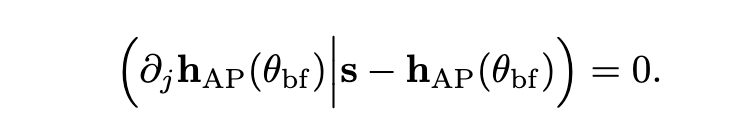

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = [1.38156360e+01, 9.99995769e+00, 8.00097281e-01, 7.49946241e+00,3.99976125e-01,
             7.85448175e-01, 9.99994074e-01, 9.00048644e-01,3.99787155e-01, 7.76287042e-05, 9.30801699e-05]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.4
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=best_fit[9]
dev_0_e=best_fit[10]
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [5]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000125.4499039067), 9.99995769, 0.800097281, 7.49946241, 0.399976125, 1.0, 0.4, 0.785448175, 0.999994074, 1, 1.0471975511965976, 0.900048644, 0.5, 0.399787155, 0.0, False, False, False, True, 7.76287042e-05, 9.30801699e-05, 0.0, 0.0, 0.0, 0.0)
SNR:  72.38877897611145


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000125.4499039067), 9.99995769, 0.800097281, 7.49946241, 0.399976125, 1.0, 0.4, 0.785448175, 0.999994074, 1, 1.0471975511965976, 0.900048644, 0.5, 0.399787155, 0.0, False, False, False, True, 7.76287042e-05, 9.30801699e-05, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 72.38877897611145
calculating stable deltas...
Gamma_ii for m1: 537.2540194436174
Gamma_ii for m1: 537.2540194177056
Gamma_ii for m1: 537.2540194234393
Gamma_ii for m1: 537.2540194232176
Gamma_ii for m1: 537.2540194085268
Gamma_ii for m1: 537.2540193659153
Gamma_ii for m1: 537.2540192118386
Gamma_ii for m1: 537.2540195432376
Gamma_ii for m1: 537.2540192159663
Gamma_ii for m1: 537.2540188002012
Gamma_ii for m1: 537.2540159624717
Gamma_ii for m1: 537.2540147049112
Gamma_ii for m1: 537.2540196291126
Gamma_ii for m1: 537.2539875311468
Gamma_ii for m1: 537.2541530283888
Gamma_ii for m1: 537.25411

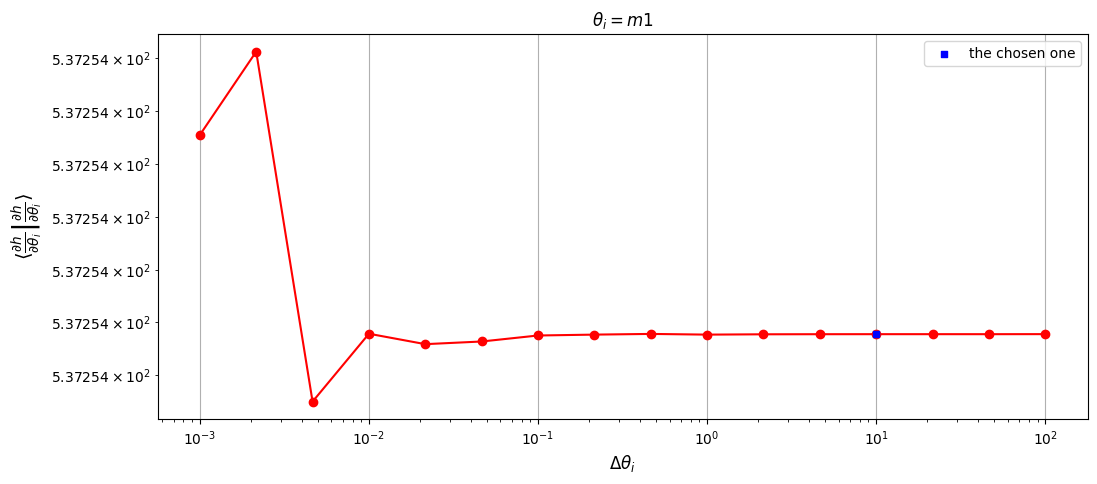

Gamma_ii for m2: 45251019152.31972
Gamma_ii for m2: 45251019150.65646
Gamma_ii for m2: 45251019148.0586
Gamma_ii for m2: 45251019155.92808
Gamma_ii for m2: 45251019144.46768
Gamma_ii for m2: 45251019111.34659
Gamma_ii for m2: 45251019091.90481
Gamma_ii for m2: 45251018957.210884
Gamma_ii for m2: 45251019307.84948
Gamma_ii for m2: 45251018895.072014
Gamma_ii for m2: 45251017720.81924
Gamma_ii for m2: 45251016955.16449
Gamma_ii for m2: 45251026417.69895
Gamma_ii for m2: 45251006637.99615
Gamma_ii for m2: 45251056291.53835
Gamma_ii for m2: 45251029351.35155
[np.float64(3.675616185885525e-11), np.float64(5.741002727811047e-11), np.float64(1.7390716198550945e-10), np.float64(2.5326271163970926e-10), np.float64(7.319413882922907e-10), np.float64(4.296429225349772e-10), np.float64(2.9765942746518294e-09), np.float64(7.748744690050132e-09), np.float64(9.121948541699363e-09), np.float64(2.5949753977784134e-08), np.float64(1.69201666289158e-08), np.float64(2.09112040346427e-07), np.float64(4.371

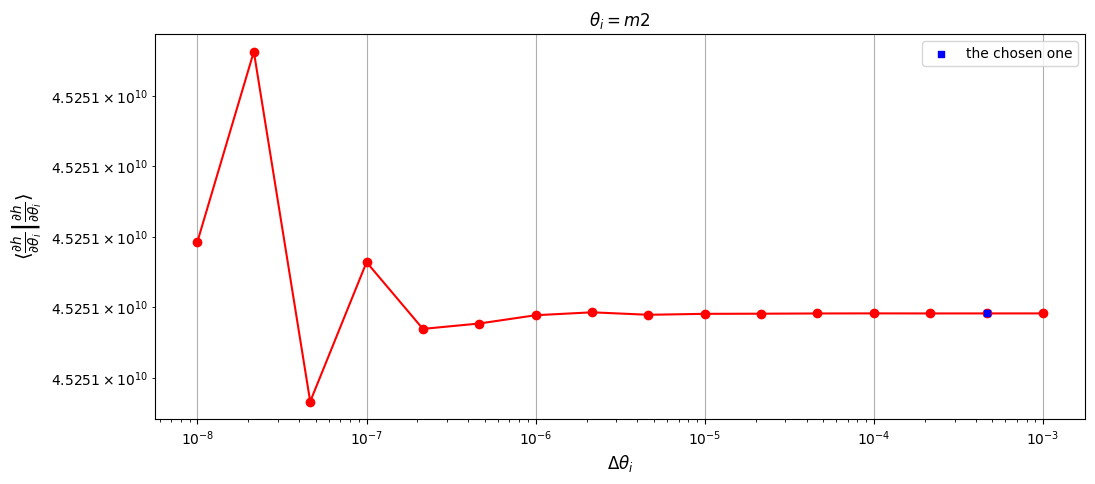

Gamma_ii for a: 2537480242828.6777
Gamma_ii for a: 2537479147068.745
Gamma_ii for a: 2537479941066.2217
Gamma_ii for a: 2537476188338.862
Gamma_ii for a: 2537480377299.027
Gamma_ii for a: 2537486955300.231
Gamma_ii for a: 2537535364088.875
Gamma_ii for a: 2537366003566.362
Gamma_ii for a: 2537498717830.031
Gamma_ii for a: 2537386343805.534
Gamma_ii for a: 2537346731001.8066
Gamma_ii for a: 2537356975464.2466
Gamma_ii for a: 2542388283269.963
Gamma_ii for a: 2549036042952.4434
Gamma_ii for a: 2534789064866.3613
Gamma_ii for a: 2576221295100.475
[np.float64(4.3183012316889053e-07), np.float64(3.1290788301911495e-07), np.float64(1.478921211993707e-06), np.float64(1.6508345059589868e-06), np.float64(2.5923290720220726e-06), np.float64(1.9077089261147926e-05), np.float64(6.67465877114855e-05), np.float64(5.2301214079996595e-05), np.float64(4.4287313507033835e-05), np.float64(1.5611900117371406e-05), np.float64(4.037454145791619e-06), np.float64(0.0019789690814831606), np.float64(0.002607950

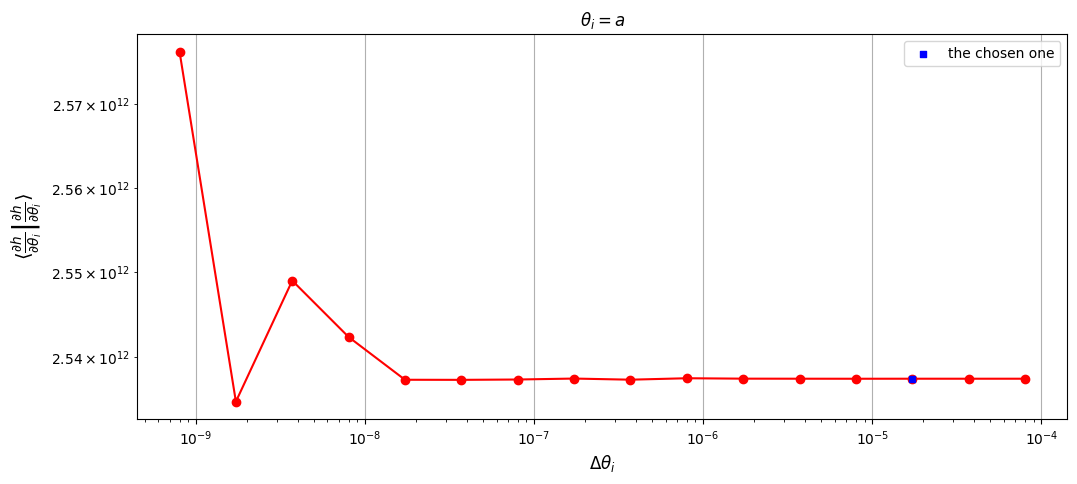

Gamma_ii for p0: 20569847024882.344
Gamma_ii for p0: 20569846607712.48
Gamma_ii for p0: 20569845870688.0
Gamma_ii for p0: 20569849384363.875
Gamma_ii for p0: 20569838984231.887
Gamma_ii for p0: 20569850146680.684
Gamma_ii for p0: 20569856108110.895
Gamma_ii for p0: 20569773052003.35
Gamma_ii for p0: 20569881504205.914
Gamma_ii for p0: 20569636218281.03
Gamma_ii for p0: 20569934800904.695
Gamma_ii for p0: 20569758580120.723
Gamma_ii for p0: 20572453982691.44
Gamma_ii for p0: 20572079959848.23
Gamma_ii for p0: 20565898785205.22
Gamma_ii for p0: 20572371785295.746
[np.float64(2.0280650178734724e-08), np.float64(3.5830335584527095e-08), np.float64(1.7081680129709229e-07), np.float64(5.056010402538214e-07), np.float64(5.426606765376102e-07), np.float64(2.89813899504472e-07), np.float64(4.037774618756898e-06), np.float64(5.272378576431023e-06), np.float64(1.1924660323589845e-05), np.float64(1.4515487120111359e-05), np.float64(8.5669835786484e-06), np.float64(0.00013101998298241507), np.float

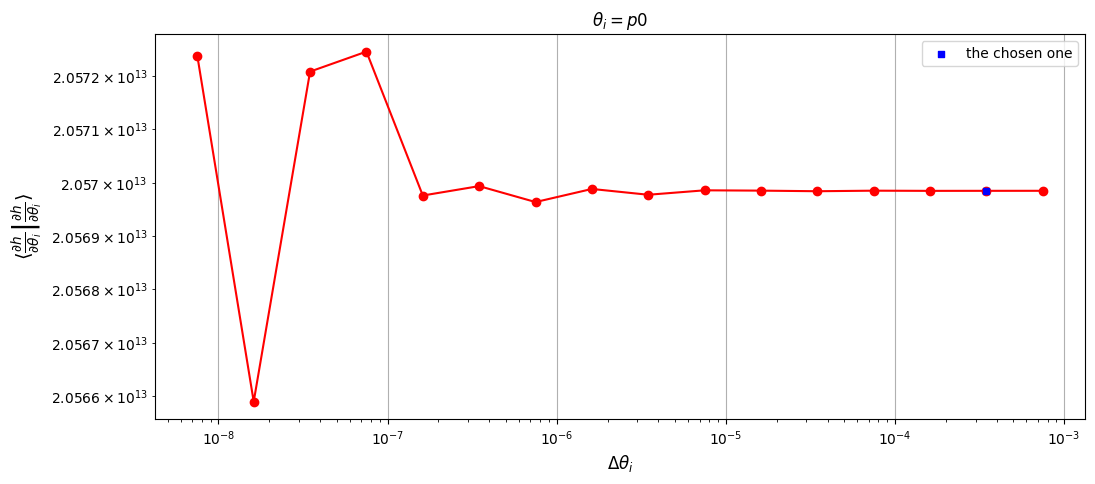

Gamma_ii for e0: 335270376307700.3
Gamma_ii for e0: 335270377412294.3
Gamma_ii for e0: 335270436059529.25
Gamma_ii for e0: 335270374746829.2
Gamma_ii for e0: 335270720844895.0
Gamma_ii for e0: 335271151268702.3
Gamma_ii for e0: 335271195326933.44
Gamma_ii for e0: 335266499615286.3
Gamma_ii for e0: 335264496270630.1
Gamma_ii for e0: 335266455636165.75
Gamma_ii for e0: 335293593690786.75
Gamma_ii for e0: 335307879216771.6
Gamma_ii for e0: 335056207118095.4
Gamma_ii for e0: 335340562203756.0
Gamma_ii for e0: 334337003721494.75
Gamma_ii for e0: 336155656369294.94
[np.float64(3.2946364320210733e-09), np.float64(1.7492516079493164e-07), np.float64(1.8287538858391146e-07), np.float64(1.0322943349789677e-06), np.float64(1.2838080630669527e-06), np.float64(1.3141072582163654e-07), np.float64(1.4005907695857666e-05), np.float64(5.975415465914329e-06), np.float64(5.844203924031462e-06), np.float64(8.09381841217854e-05), np.float64(4.260420607545466e-05), np.float64(0.0007511339689568698), np.floa

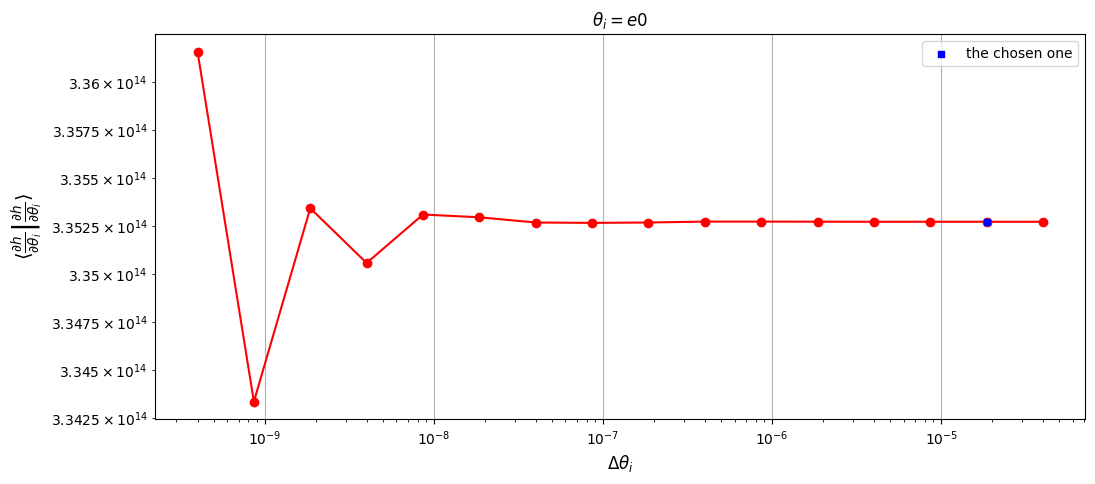

Gamma_ii for qS: 16148.245869538618
Gamma_ii for qS: 16148.245891673156
Gamma_ii for qS: 16148.245891721683
Gamma_ii for qS: 16148.245891721795
Gamma_ii for qS: 16148.245891722003
Gamma_ii for qS: 16148.24589172244
Gamma_ii for qS: 16148.245891719924
Gamma_ii for qS: 16148.245891723433
Gamma_ii for qS: 16148.245891723915
Gamma_ii for qS: 16148.245891711296
Gamma_ii for qS: 16148.24589168858
Gamma_ii for qS: 16148.245891731787
Gamma_ii for qS: 16148.245891718592
Gamma_ii for qS: 16148.245891852748
Gamma_ii for qS: 16148.245892441959
Gamma_ii for qS: 16148.245891010378
[np.float64(1.3707085112258015e-09), np.float64(3.0050941528375834e-12), np.float64(6.983875758150119e-15), np.float64(1.2841319942404892e-14), np.float64(2.7034357773483255e-14), np.float64(1.5578548666972153e-13), np.float64(2.1728865060435828e-13), np.float64(2.9850436708218366e-14), np.float64(7.814055828115948e-13), np.float64(1.4066877494831947e-12), np.float64(2.675612917471567e-12), np.float64(8.17113463703726e-13)

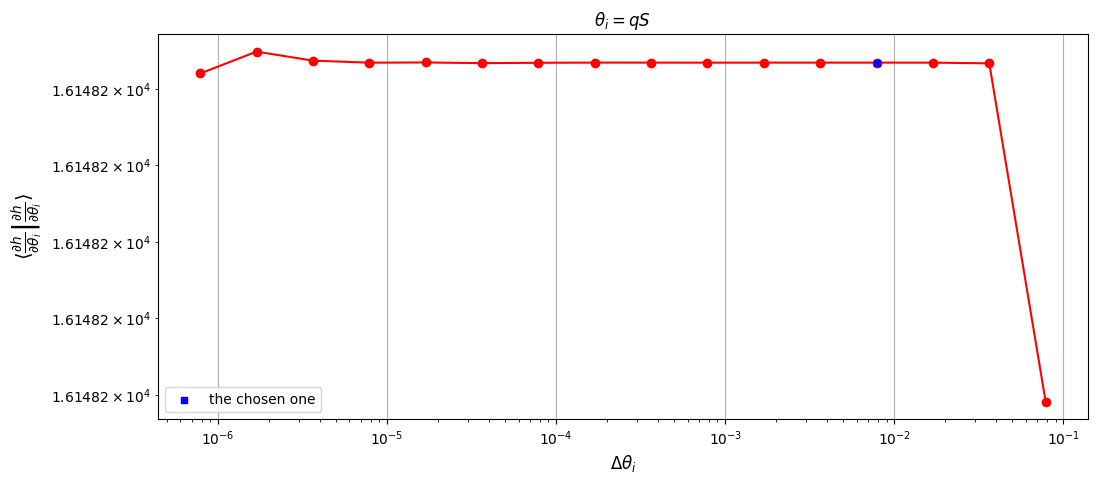

Gamma_ii for phiS: 310677.5629339771
Gamma_ii for phiS: 310677.56292929477
Gamma_ii for phiS: 310677.56292928447
Gamma_ii for phiS: 310677.56292928447
Gamma_ii for phiS: 310677.56292928447
Gamma_ii for phiS: 310677.56292928447
Gamma_ii for phiS: 310677.56292928447
Gamma_ii for phiS: 310677.56292928447
Gamma_ii for phiS: 310677.56292928447
Gamma_ii for phiS: 310677.56292928447
Gamma_ii for phiS: 310677.5629292846
Gamma_ii for phiS: 310677.5629292844
Gamma_ii for phiS: 310677.562929285
Gamma_ii for phiS: 310677.5629292861
Gamma_ii for phiS: 310677.5629292826
Gamma_ii for phiS: 310677.562929292
[np.float64(1.5071383382348634e-11), np.float64(3.316221449834411e-14), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(3.747142881168824e-16), np.float64(5.62071432175324e-16), np.float64(1.8735714405844098e-15), np.float64(3.559785737110366e-15), np.float64(1.1241428643506545e-14), np.float64(3.0164500193408315e-14)

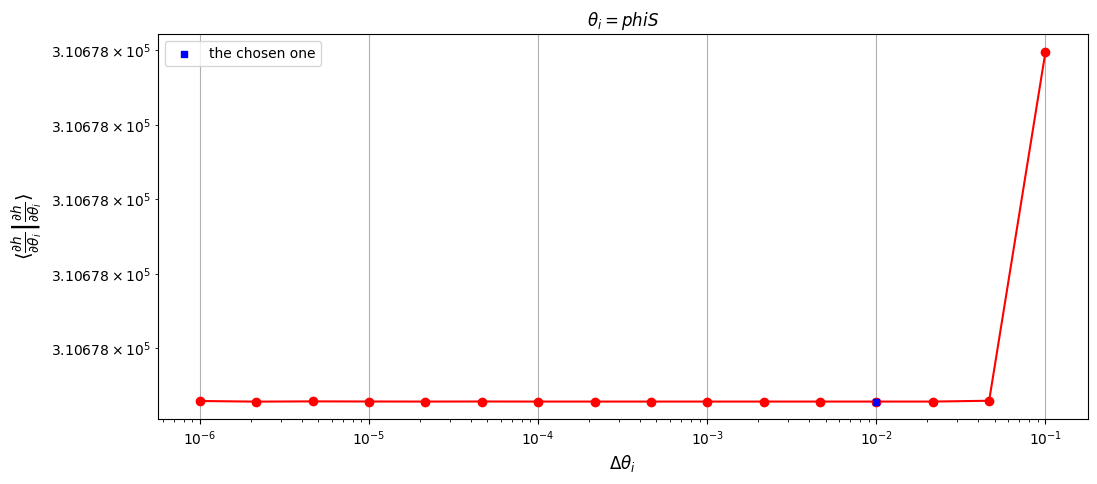

Gamma_ii for dev0p: 2626864213701.5366
Gamma_ii for dev0p: 2626856523230.4604
Gamma_ii for dev0p: 2626872208433.1895
Gamma_ii for dev0p: 2626919183626.0425
Gamma_ii for dev0p: 2626956873509.6675
Gamma_ii for dev0p: 2626737728652.379
Gamma_ii for dev0p: 2626663858533.31
Gamma_ii for dev0p: 2626879661307.6553
Gamma_ii for dev0p: 2625255458673.5967
Gamma_ii for dev0p: 2629958887842.0825
Gamma_ii for dev0p: 2627013033882.941
Gamma_ii for dev0p: 2626516204574.005
Gamma_ii for dev0p: 2654454496045.911
Gamma_ii for dev0p: 2647731032975.591
Gamma_ii for dev0p: 2677363418391.0776
Gamma_ii for dev0p: 3118490393777.1855
[np.float64(2.9276327078245877e-06), np.float64(5.9710566348255746e-06), np.float64(1.788223754496535e-05), np.float64(1.4347355301134256e-05), np.float64(8.342852615171606e-05), np.float64(2.8123171843577896e-05), np.float64(8.215175499809103e-05), np.float64(0.0006186836517918213), np.float64(0.0017884040660213773), np.float64(0.0011213701345011552), np.float64(0.000189159049569

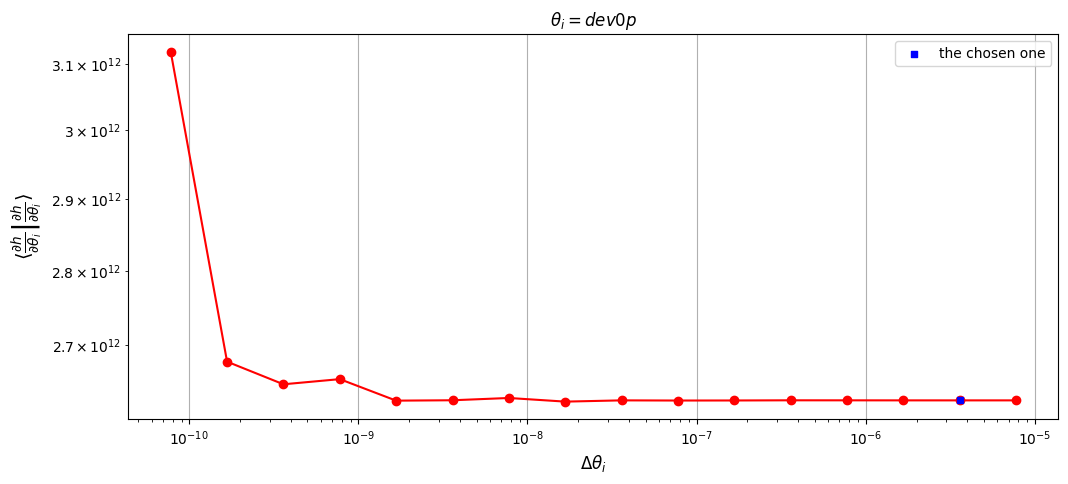

Gamma_ii for dev0e: 258479091825.18378
Gamma_ii for dev0e: 258475400315.06973
Gamma_ii for dev0e: 258470859837.5981
Gamma_ii for dev0e: 258486269206.59024
Gamma_ii for dev0e: 258460815471.2255
Gamma_ii for dev0e: 258446607679.4848
Gamma_ii for dev0e: 258510897170.60248
Gamma_ii for dev0e: 258200842042.9904
Gamma_ii for dev0e: 258478621438.53418
Gamma_ii for dev0e: 259561216777.95264
Gamma_ii for dev0e: 257906936363.0193
Gamma_ii for dev0e: 257454153490.989
Gamma_ii for dev0e: 249968169687.57962
Gamma_ii for dev0e: 224983137268.09958
Gamma_ii for dev0e: 262100542114.58932
Gamma_ii for dev0e: 223620386682.27448
[np.float64(1.4281862450138029e-05), np.float64(1.756669001090303e-05), np.float64(5.9613878290033346e-05), np.float64(9.848198969092808e-05), np.float64(5.497379852751666e-05), np.float64(0.00024869160960455905), np.float64(0.0012008292659265107), np.float64(0.0010746706787503053), np.float64(0.004170867099704603), np.float64(0.006414253289430153), np.float64(0.001758693211551240

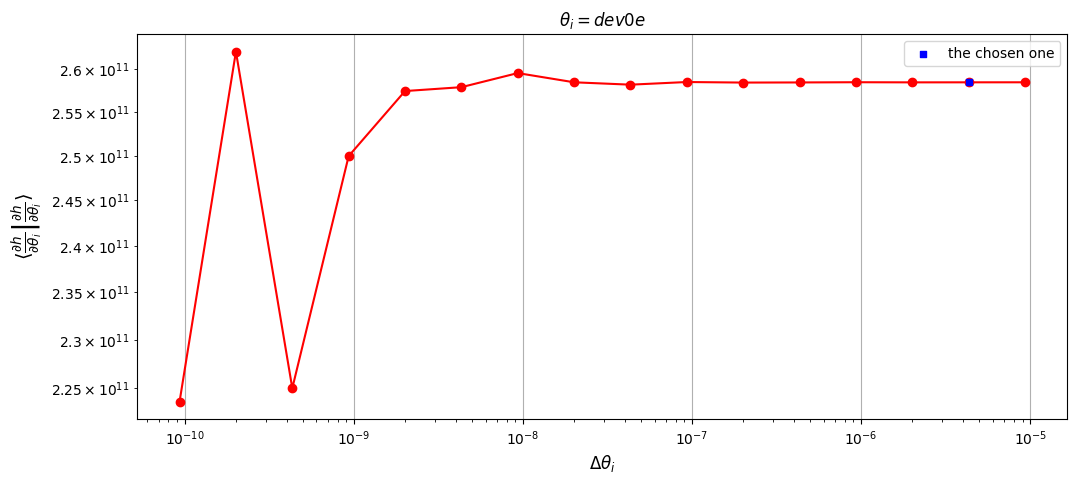

stable deltas: {'m1': 10.001254499039067, 'm2': 0.0004641569195050422, 'a': 1.7237573375865878e-05, 'p0': 0.0003480942098035478, 'e0': 1.8565247155117094e-05, 'qS': 0.007854481750000001, 'phiS': 0.00999994074, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 3.6032052658254976e-06, 'dev0e': 4.320398772386205e-06}
Time taken to compute stable deltas is 155.06388902664185 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 10.286993980407715 seconds


In [6]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [7]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.8, 7.5, 0.4, np.pi/4, 1.0,  0.9,0.4,0,0])

In [8]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8,9,10
0,5.373888e+14,-4.796110e+12,2.550340e+13,1.050379e+14,4.227824e+14,-2.391450e+09,1.102894e+10,-2.891398e+09,-2.544273e+09,-3.635677e+13,-1.160589e+13
1,-4.796110e+12,4.525102e+10,-2.623191e+11,-9.435431e+11,-3.692796e+12,1.929236e+07,-8.896801e+07,2.332479e+07,1.942153e+07,3.446772e+11,1.078451e+11
2,2.550340e+13,-2.623191e+11,2.537480e+12,5.212842e+12,1.896724e+13,-1.082258e+08,4.993610e+08,-1.311258e+08,-4.628225e+07,-2.025635e+12,-5.976046e+11
3,1.050379e+14,-9.435431e+11,5.212842e+12,2.056985e+13,8.244379e+13,-4.663325e+08,2.150683e+09,-5.638688e+08,-4.843073e+08,-7.158911e+12,-2.276820e+12
4,4.227824e+14,-3.692796e+12,1.896724e+13,8.244379e+13,3.352704e+14,-1.951178e+09,8.998635e+09,-2.359115e+09,-2.110690e+09,-2.794024e+13,-8.989011e+12
5,-2.391450e+09,1.929236e+07,-1.082258e+08,-4.663325e+08,-1.951178e+09,1.614825e+04,-6.713831e+04,1.760559e+04,1.504637e+04,1.455249e+08,4.740501e+07
6,1.102894e+10,-8.896801e+07,4.993610e+08,2.150683e+09,8.998635e+09,-6.713831e+04,3.106776e+05,-8.121414e+04,-6.938493e+04,-6.711069e+08,-2.186120e+08
7,-2.891398e+09,2.332479e+07,-1.311258e+08,-5.638688e+08,-2.359115e+09,1.760559e+04,-8.121414e+04,2.130007e+04,1.818151e+04,1.759478e+08,5.731013e+07
8,-2.544273e+09,1.942153e+07,-4.628225e+07,-4.843073e+08,-2.110690e+09,1.504637e+04,-6.938493e+04,1.818151e+04,2.089932e+04,1.450764e+08,4.914867e+07
9,-3.635677e+13,3.446772e+11,-2.025635e+12,-7.158911e+12,-2.794024e+13,1.455249e+08,-6.711069e+08,1.759478e+08,1.450764e+08,2.626857e+12,8.200066e+11


In [9]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):
    """
    Plots 2D 90% and 99% confidence ellipses onto ax.
    mean: (D,) best-fit vector
    cov:  (D,D) covariance
    i,j: indices of parameters
    """
    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D-1 and j == 0:
                    # ellipse handles
                    for item in ax.get_lines():
                        if "10%" in item.get_label() or "90%" in item.get_label():
                            legend_handles.append(item)
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


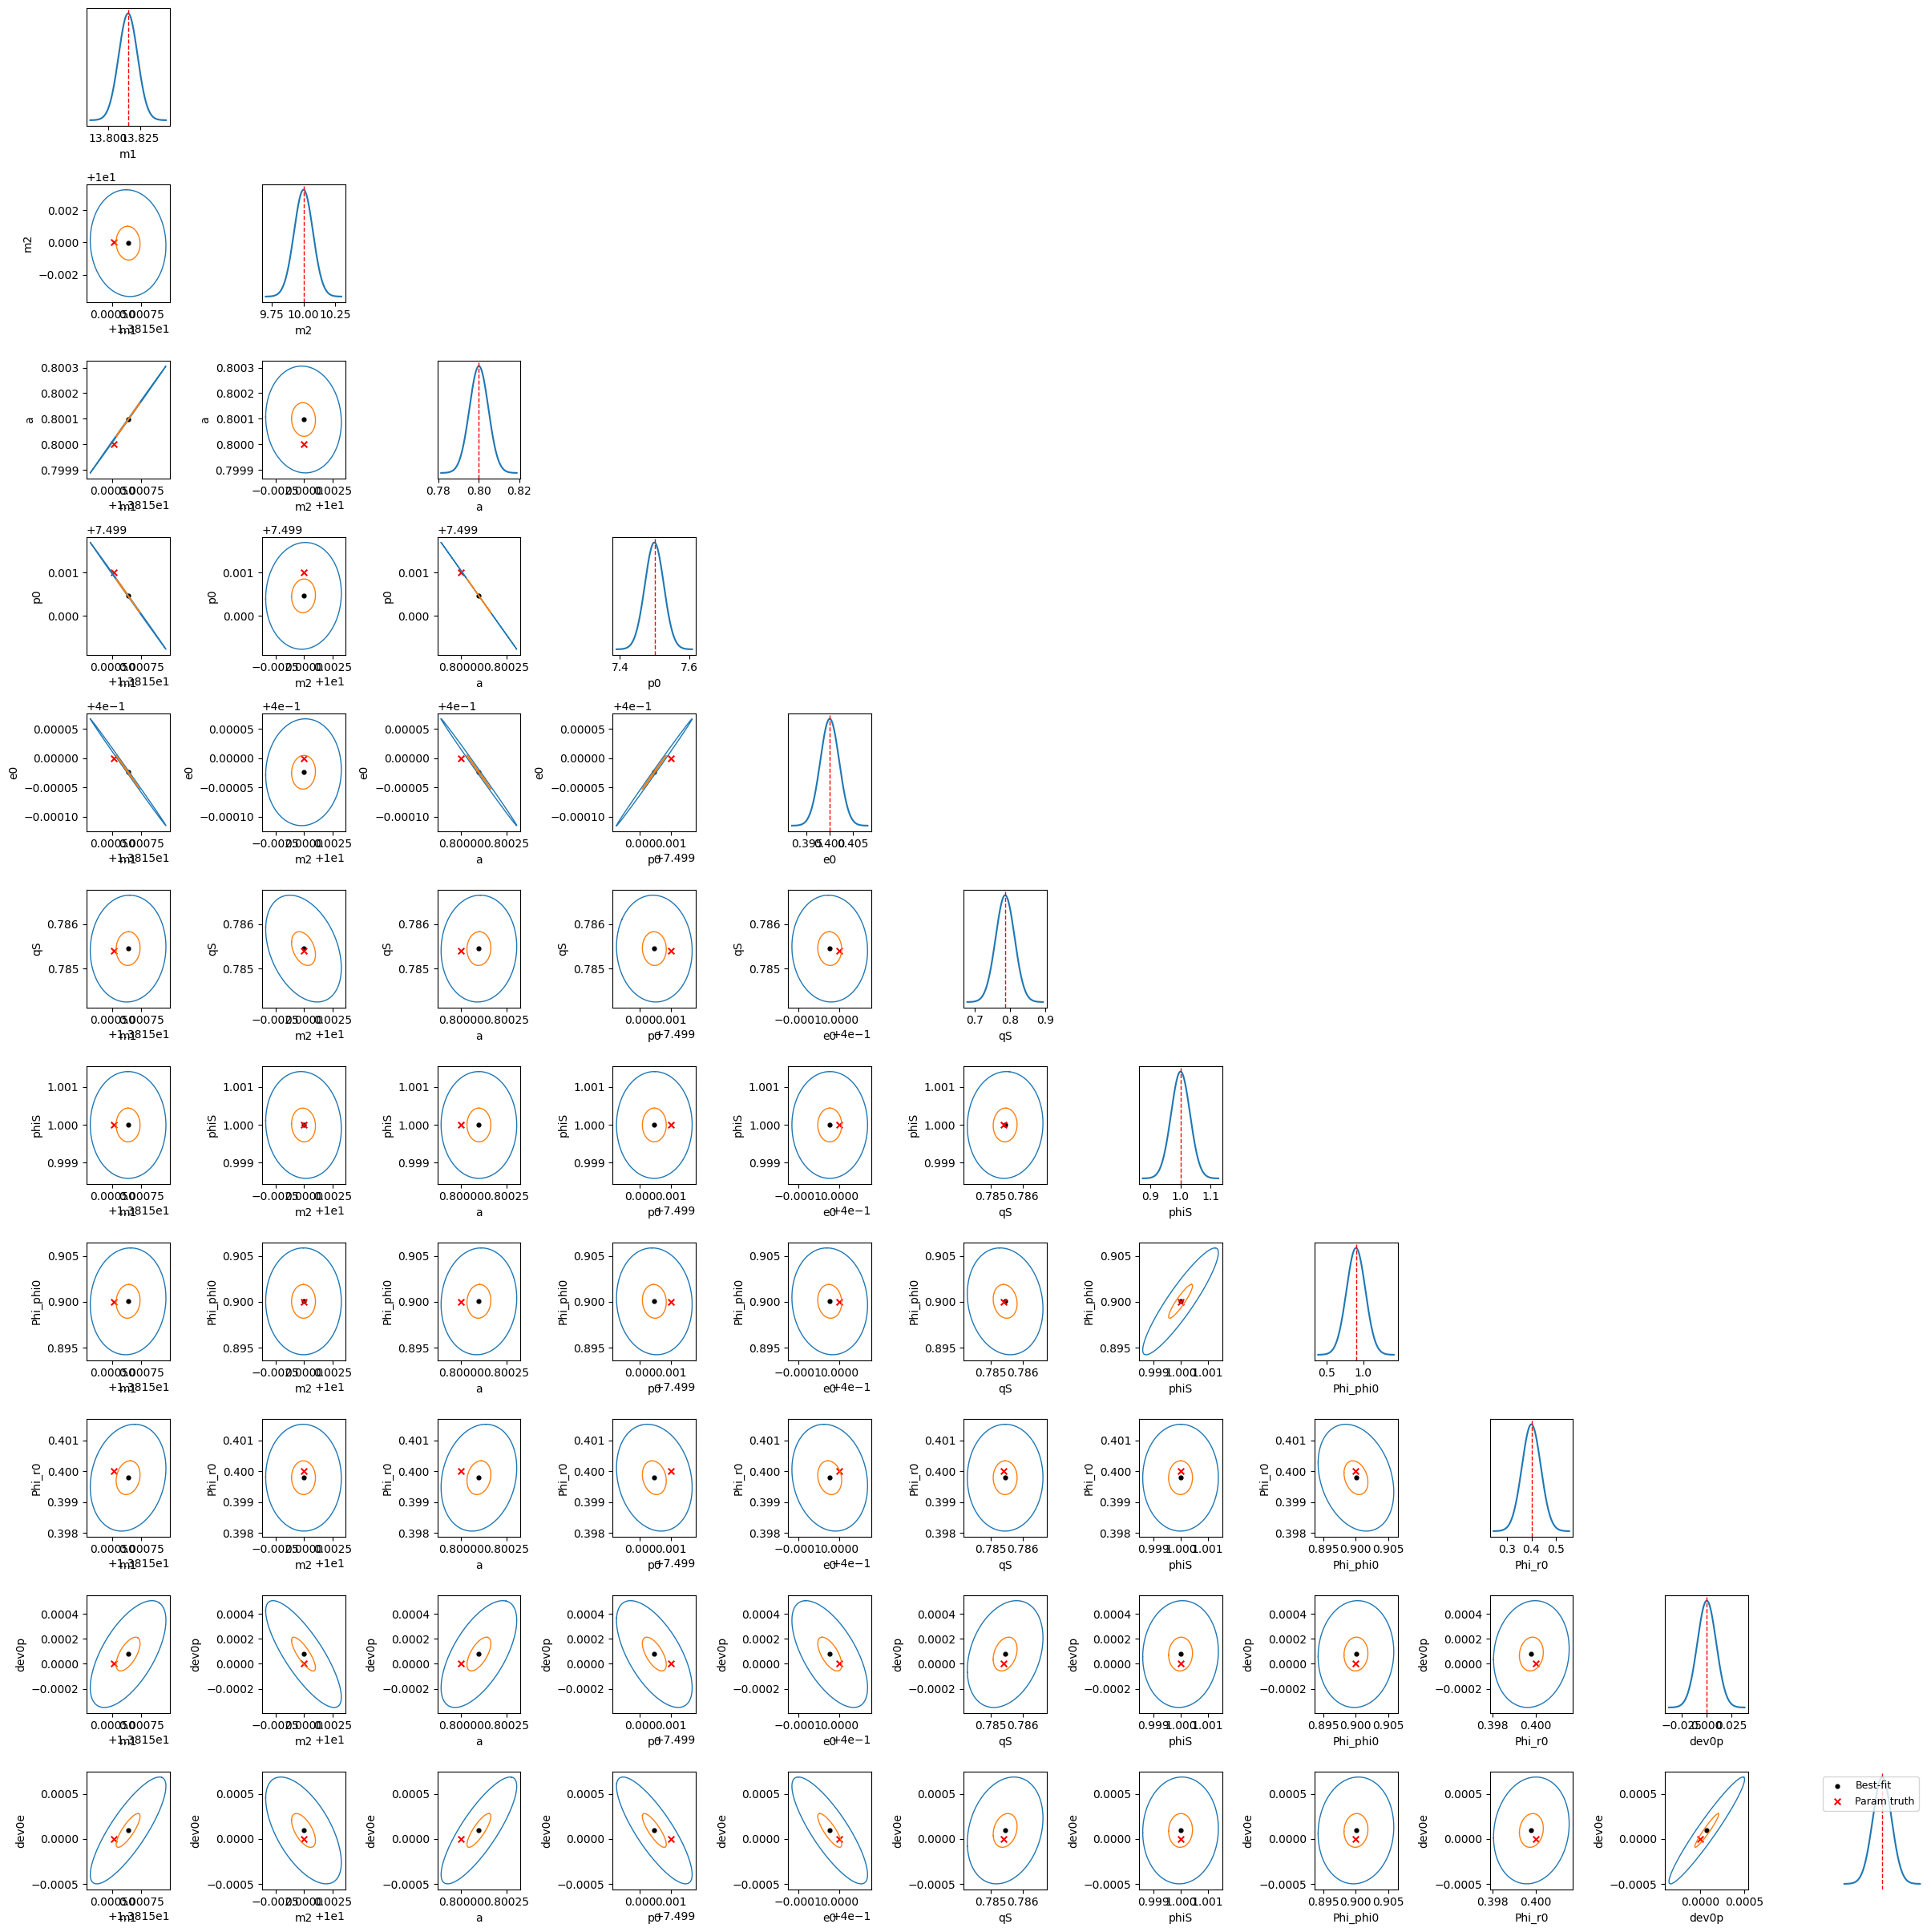

In [10]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.001, 0.0001])


In [22]:
# True waveform with 1PA order
m1_true = 1e6
m2_true = 10
a_true = 0.8 
e0_true = 0.4 
xI0_true = 1.0
dist_true = 0.4
qS_true = xp.pi/4
phiS_true = 1.0
qK_true = 1 
phiK_true = xp.pi/3
Phi_phi0_true = 0.9
Phi_theta0_true =0.5
Phi_r0_true = 0.4
p0_true=7.5
chi2 = 0.0
dev_0_p_true=0.0
dev_0_e_true=0.0

evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])




In [23]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [24]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)

# waveform analysis and p0 evolution 

In [25]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=0.5, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should+0.1)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  6.439843289124535
separatrix p:  3.3636344376256564


# P evolution is done considering true waveform (1PA)

[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


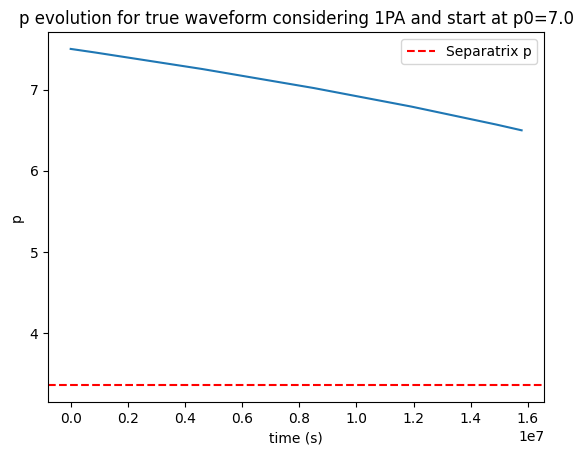

In [26]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.0')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

# Waveform Visualization

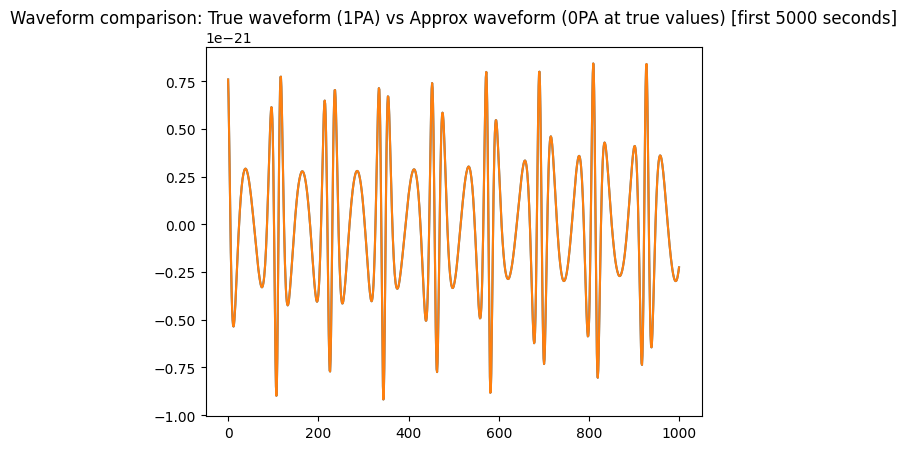

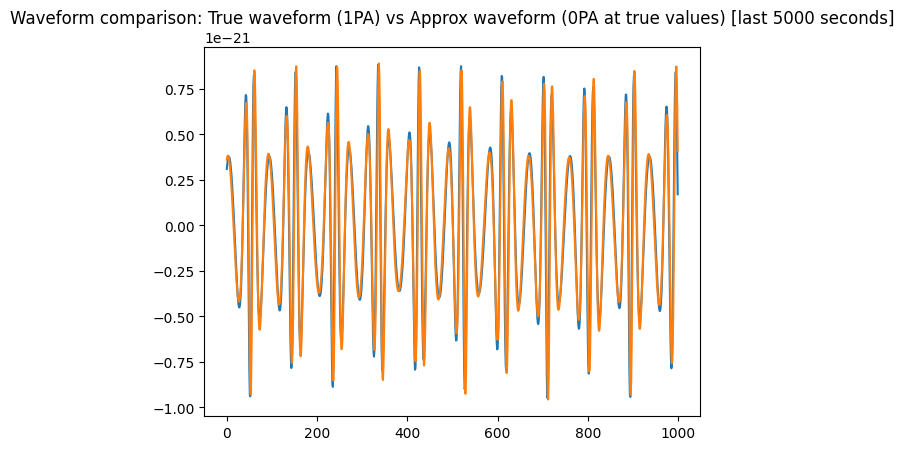

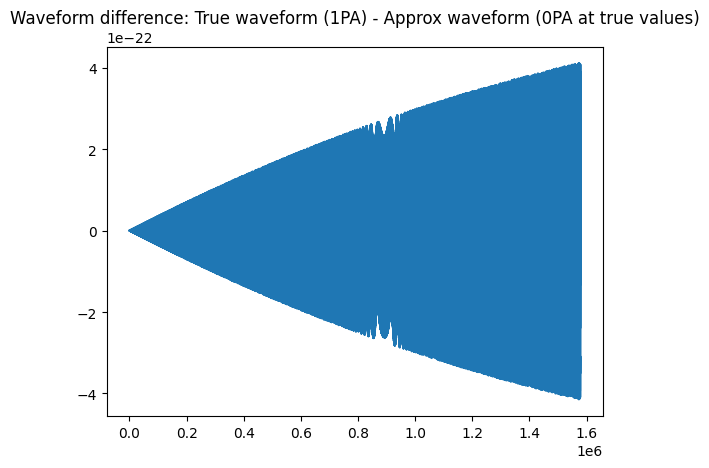

In [27]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

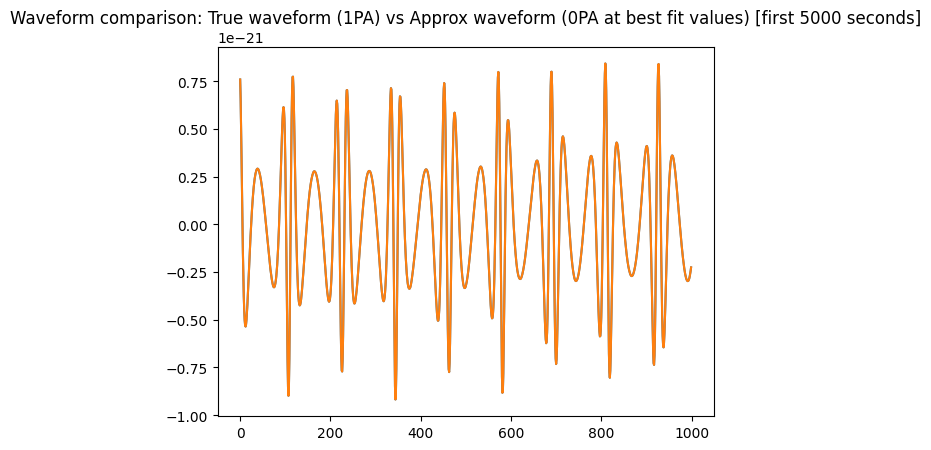

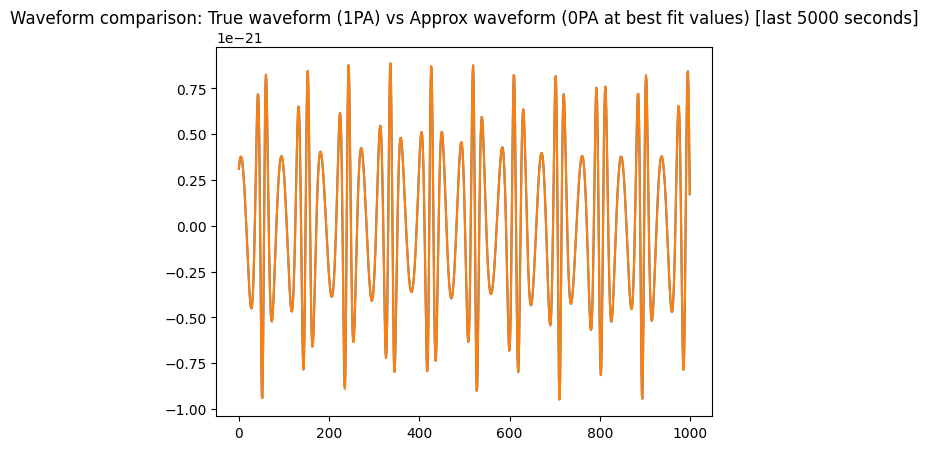

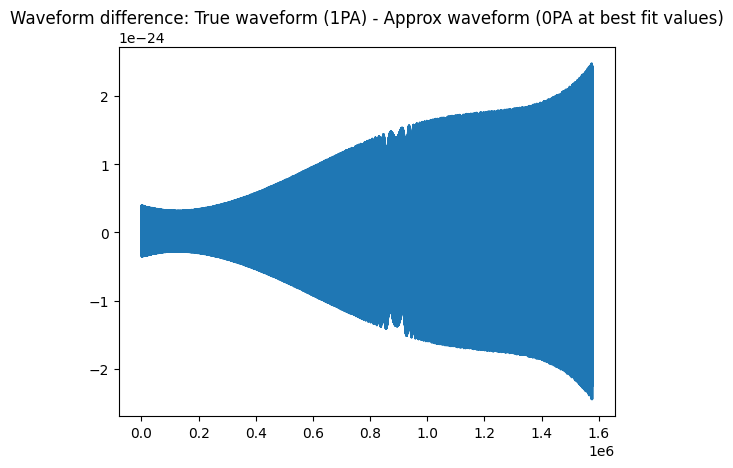

In [28]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

# Overlap and mismatch

In [29]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.9999991695055781
mismatch between best fit point and true waveform: 8.304944218995303e-07
overlap between approximate waveform and true waveform (both at true points) 0.9730095866032549
mismatch between approximate waveform and true waveform (both at true points): 0.026990413396745128


# table true vs bias

In [32]:
best_fit


[np.float64(1000125.4499039067),
 9.99995769,
 0.800097281,
 7.49946241,
 0.399976125,
 0.785448175,
 0.999994074,
 0.900048644,
 0.399787155,
 7.76287042e-05,
 9.30801699e-05]

In [33]:
import pandas as pd
best_fit[0] = np.exp(13.815636)
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true,dev_0_p_true,dev_0_e_true]
df = pd.DataFrame({'Best Fit': best_fit, 'True Param': truue_param}, index=param_names)
print(df)

              Best Fit      True Param
m1        1.000125e+06  1000000.000000
m2        9.999958e+00       10.000000
a         8.000973e-01        0.800000
p0        7.499462e+00        7.500000
e0        3.999761e-01        0.400000
qS        7.854482e-01        0.785398
phiS      9.999941e-01        1.000000
Phi_phi0  9.000486e-01        0.900000
Phi_r0    3.997872e-01        0.400000
dev0p     7.762870e-05        0.000000
dev0e     9.308017e-05        0.000000


In [21]:
# #Orthoganal check between derivative and exact fisher matrices
# PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
#                 noise_PSD=get_sensitivity,
#                 noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
#                 channels=["A","E"])
# inner_val = []
# for i in range(fisher_derivs.shape[0]):
#     temp_deriv = inner_product(fisher_derivs[i],waveform_true-sef.waveform, PSD=PSD, dt=dt,use_gpu=use_gpu)
#     inner_val.append(temp_deriv)
